In [919]:
import requests
from io import StringIO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [920]:
df = StringIO(requests.get('https://raw.githubusercontent.com/rajtilakls2510/car_price_predictor/refs/heads/master/quikr_car.csv').text)
df = pd.read_csv(df)
backdup = df.copy()

In [921]:
df.sample(4)

,name,company,year,Price,kms_driven,fuel_type
85,I want to sell my car Tata Zest,I,2017,Ask For Price,NaN,NaN
460,Maruti Suzuki Baleno Delta 1.2,Maruti,2016,"5,00,000","28,000 kms",Petrol
182,Hyundai i20,Hyundai,2009,"1,99,000","31,000 kms",Petrol
566,Force Motors One SUV,Force,2013,"5,50,000","1,40,000 kms",Diesel


## PROBLEMS IN DATASET
- convert categorical columns into lowercase.
- filter out noise from company.
- filter out noise from year.
- remove 'Ask For Price' from Price.
- remove values of kms_driven with no kms at end ('Petrol') and remove kms from end.
- remove noise from name column

In [922]:
df.dtypes

name          str
company       str
year          str
Price         str
kms_driven    str
fuel_type     str
dtype: object

In [923]:
df['company'].unique()

<StringArray>
[   'Hyundai',   'Mahindra',     'Maruti',       'Ford',      'Skoda',
       'Audi',     'Toyota',    'Renault',      'Honda',     'Datsun',
 'Mitsubishi',       'Tata', 'Volkswagen',          'I',  'Chevrolet',
       'Mini',        'BMW',     'Nissan',  'Hindustan',       'Fiat',
 'Commercial',     'MARUTI',      'Force',   'Mercedes',       'Land',
     'Yamaha',    'selling',     'URJENT',      'Swift',       'Used',
     'Jaguar',       'Jeep',       'tata',       'Sale',       'very',
      'Volvo',          'i',       '2012',       'Well',        'all',
          '7',          '9',    'scratch',     'urgent',       'sell',
       'TATA',        'Any',       'Tara']
Length: 48, dtype: str

In [924]:
valid_brands = [
    'hyundai','mahindra','maruti','ford','skoda','audi','toyota',
    'renault','honda','datsun','mitsubishi','tata','volkswagen',
    'chevrolet','mini','bmw','nissan','hindustan','fiat','force',
    'mercedes','jaguar','jeep','volvo','land rover'
]

In [925]:
df['year'].unique()

<StringArray>
['2007', '2006', '2018', '2014', '2015', '2012', '2013', '2016', '2010',
 '2017', '2008', '2011', '2019', '2009', '2005', '2000',  '...', '150k',
 'TOUR', '2003', 'r 15', '2004', 'Zest', '/-Rs', 'sale', '1995', 'ara)',
 '2002', 'SELL', '2001', 'tion', 'odel', '2 bs', 'arry',  'Eon', 'o...',
 'ture',  'emi',  'car', 'able',  'no.', 'd...', 'SALE', 'digo', 'sell',
 'd Ex', 'n...', 'e...', 'D...', ', Ac', 'go .', 'k...', 'o c4', 'zire',
 'cent', 'Sumo',  'cab', 't xe',  'EV2', 'r...', 'zest']
Length: 61, dtype: str

In [926]:
len(df[df['Price'] == 'Ask For Price'])

35

In [927]:
df['kms_driven'].value_counts()

kms_driven
45,000 kms      30
35,000 kms      30
55,000 kms      25
50,000 kms      23
20,000 kms      22
                ..
1,46,000 kms     1
1,00,800 kms     1
2,100 kms        1
2,500 kms        1
1,32,000 kms     1
Name: count, Length: 258, dtype: int64

In [928]:
df['fuel_type'].value_counts()

fuel_type
Petrol    440
Diesel    395
LPG         2
Name: count, dtype: int64

In [929]:
df['name'].value_counts()

name
Honda City                    13
Honda Amaze                   11
Maruti Suzuki Dzire           10
Mahindra Scorpio S10           9
Maruti Suzuki Alto 800 Lxi     9
                              ..
Tata Indica V2 DLE BS III      1
Ta                             1
Tata Zest XM Diesel            1
Honda Amaze 1.2 E i VTEC       1
Chevrolet Sail 1.2 LT ABS      1
Name: count, Length: 525, dtype: int64

In [930]:
def make_lower(column):
    df[column] = df[column].str.lower().str.strip()

In [931]:
make_lower('company')
df = df[df['company'].isin(valid_brands)]
df['company']

0        hyundai
1       mahindra
2         maruti
3        hyundai
4           ford
         ...    
886       toyota
888         tata
889     mahindra
890        honda
891    chevrolet
Name: company, Length: 861, dtype: str

In [932]:
df = df[df['year'].str[1] == '0']
df['year'] = df['year'].astype(int)

In [933]:
df.shape

(837, 6)

In [934]:
df = df[df['Price'] != 'Ask For Price']

In [935]:
df['Price'] = df['Price'].str.strip(' ').str.replace(',', '').astype(int)
df.shape

(816, 6)

In [936]:
df = df[df['kms_driven'].str.contains("kms")]
df.shape

(814, 6)

In [937]:
df['kms_driven'] = df['kms_driven'].str.replace(',', '').str.strip('kms').astype(int)
df['kms_driven'].unique()

array([ 45000,     40,  28000,  36000,  41000,  25000,  24530,  60000,
        30000,  32000,  48660,   4000,  16934,  43000,  35550,  39522,
        39000,  55000,  72000,  15975,  70000,  23452,  35522,  48508,
        15487,  82000,  20000,  68000,  38000,  27000,  33000,  46000,
        16000,  47000,  35000,  30874,  15000,  29685, 130000,  19000,
        54000,  13000,  38200,  22000,  50000,  13500,   3600,  45863,
        60500,  12500,  18000,  13349,  29000,  44000,  42000,  14000,
        49000,  36200,  51000, 104000,  33333,  33600,   5600,   7500,
        26000,  24330,  65480, 200000,  59000,  99000,   2800,  21000,
        11000,  66000,   3000,   7000,  38500,  37200,  43200,  24800,
        45872,  40000,  11400,  97200,  52000,  31000, 175430,  37000,
        65000,   3350,  75000,  62000,  73000,   2200,  54870,  34580,
        97000,     60,  80200,   3200,      0,   5000,    588,  71200,
       175400,   9300,  56758,  10000,  56450,  56000,  32700,   9000,
      

In [938]:
df.shape

(814, 6)

In [939]:
df.isnull().sum()

name          0
company       0
year          0
Price         0
kms_driven    0
fuel_type     1
dtype: int64

In [940]:
df.dropna(inplace=True)

In [941]:
df.shape

(813, 6)

In [942]:
df.duplicated().sum()

np.int64(92)

In [943]:
df.drop_duplicates(keep='first', inplace=True)

In [944]:
df.shape

(721, 6)

In [945]:
df['name'] = df['name'].str.lower().str.strip(' ')

In [946]:
df['name'].unique()

<StringArray>
[  'hyundai santro xing xo erlx euro iii',
                'mahindra jeep cl550 mdi',
 'hyundai grand i10 magna 1.2 kappa vtvt',
       'ford ecosport titanium 1.5l tdci',
                              'ford figo',
                            'hyundai eon',
       'ford ecosport ambiente 1.5l tdci',
         'maruti suzuki alto k10 vxi amt',
            'skoda fabia classic 1.2 mpi',
             'maruti suzuki stingray vxi',
 ...
                     'mahindra quanto c4',
              'maruti suzuki swift dzire',
             'hyundai i20 select variant',
                   'honda city vx petrol',
                           'hyundai getz',
         'mercedes benz c class 200 k mt',
                            'skoda fabia',
             'maruti suzuki ritz vxi abs',
              'tata indica v2 dle bs iii',
                    'tata zest xm diesel']
Length: 460, dtype: str

In [947]:
df.sample(5)

,name,company,year,Price,kms_driven,fuel_type
477,maruti suzuki baleno delta 1.2,maruti,2016,498000,22000,Petrol
632,hyundai elite i20 sportz 1.2,hyundai,2017,550000,15000,Petrol
386,hyundai verna 1.4 vtvt,hyundai,2014,375000,36000,Petrol
705,ford ecosport trend 1.5l tdci,ford,2014,400000,16000,Petrol
651,mahindra tuv300 t4 plus,mahindra,2016,540000,29500,Diesel


In [948]:
df.dtypes

name            str
company         str
year          int64
Price         int64
kms_driven    int64
fuel_type       str
dtype: object

In [949]:
df.describe()

,year,Price,kms_driven
count,721.000000,7.210000e+02,721.000000
mean,2012.366158,4.009285e+05,46816.826630
std,4.027912,4.767375e+05,34638.439871
min,2000.000000,3.000000e+04,0.000000
25%,2010.000000,1.650000e+05,27000.000000
50%,2013.000000,2.900000e+05,42000.000000
75%,2015.000000,4.899990e+05,59000.000000
max,2019.000000,8.500003e+06,400000.000000


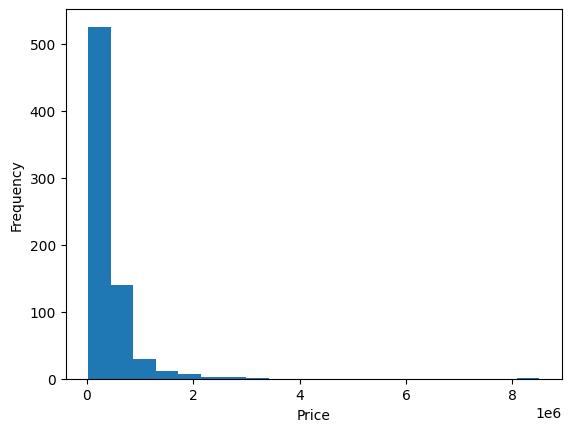

In [950]:
plt.hist(df['Price'], bins=20)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [951]:
len(df[df['Price'] > df['Price'].quantile(0.95)])

36

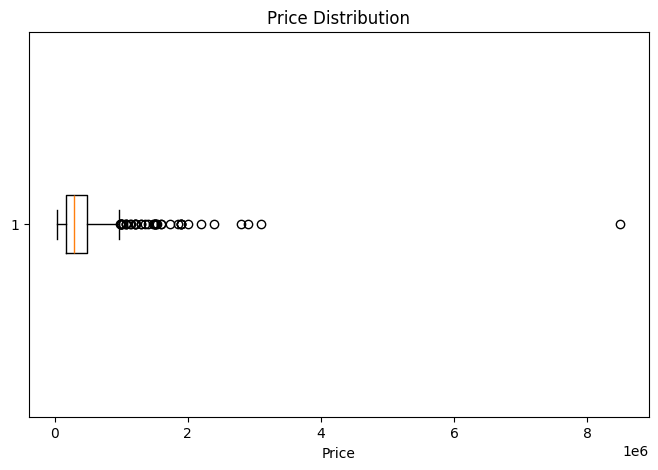

In [952]:
plt.figure(figsize=(8,5))
plt.boxplot(df['Price'], vert=False)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.show()

<Figure size 1200x800 with 0 Axes>

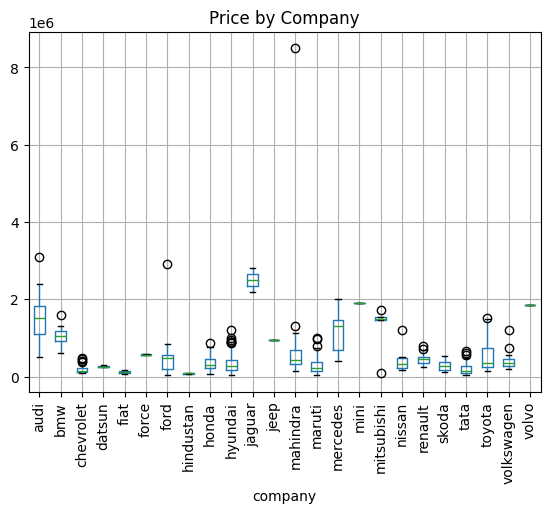

In [953]:
plt.figure(figsize=(12,8))
df.boxplot(column='Price', by='company', rot=90)
plt.title('Price by Company')
plt.suptitle('')
plt.show()

In [954]:
q1 = df['Price'].quantile(0.25)
q3 = df['Price'].quantile(0.75)
iqr = q3 - q1
lowerbound = q1 - 1.5 * iqr
upperbound = q3 + 1.5 * iqr

In [955]:
df['Price'] = df['Price'].clip(lowerbound, upperbound)   #44
# df = df[(df['Price'] >= lowerbound) & (df['Price'] <= upperbound)] 22
df.dtypes

name              str
company           str
year            int64
Price         float64
kms_driven      int64
fuel_type         str
dtype: object

In [956]:
def remove_cmpny_name(name):
    model = []
    for word in name.split():
        if word not in df['company'].unique():
            model.append(word)

    return (" ").join(model)

In [957]:
df['model'] = df['name'].apply(remove_cmpny_name)
car = df[['name', 'company']]
car.to_csv('data.csv', index=False)
df.drop(columns=['name'], inplace=True)

In [958]:
df.sample(5)

,company,year,Price,kms_driven,fuel_type,model
136,maruti,2013,340000.0,41000,Petrol,suzuki swift dzire vxi 1.2 bs iv
588,hyundai,2011,175000.0,30000,Petrol,i10 era
496,honda,2013,250000.0,55700,Diesel,amaze
459,honda,2017,760000.0,4000,Petrol,city sv
596,renault,2015,385000.0,51000,Diesel,duster 85 ps rxl diesel


In [959]:
from sklearn.model_selection import train_test_split
X = df[["year", "kms_driven", "fuel_type", "company", "model"]]
y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [960]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
ohe.fit(X[['model', 'company', 'fuel_type']])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_catego

In [961]:
from sklearn.compose import ColumnTransformer
transfomer = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(categories=ohe.categories_, handle_unknown='ignore'), ['model', 'company', 'fuel_type'])
    ],
    remainder='passthrough'
)

In [962]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [963]:
pipe = Pipeline([
    ("ct", transfomer),
    ("model", lr)
])

In [964]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ct', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse mat

In [965]:
pipe.named_steps

{'ct': ColumnTransformer(remainder='passthrough',
                   transformers=[('ohe',
                                  OneHotEncoder(categories=[array(['3 series 320d sedan', '3 series 320i', '5 series 520d sedan',
        '5 series 530i', '7 series 740li sedan', 'a3 cabriolet 40 tfsi',
        'a4 1.8 tfsi multitronic premium plus',
        'a4 2.0 tdi 177bhp premium', 'a6 2.0 tdi premium', 'a8', 'accent',
        'accent executive edition', 'accent gle', 'accent glx', 'accord',...
       dtype=object),
                                                            array(['audi', 'bmw', 'chevrolet', 'datsun', 'fiat', 'force', 'ford',
        'hindustan', 'honda', 'hyundai', 'jaguar', 'jeep', 'mahindra',
        'maruti', 'mercedes', 'mini', 'mitsubishi', 'nissan', 'renault',
        'skoda', 'tata', 'toyota', 'volkswagen', 'volvo'], dtype=object),
                                                            array(['Diesel', 'LPG', 'Petrol'], dtype=object)],
                         

In [966]:
y_pred = pipe.predict(X_test)
# ohe.categories_
# X

In [967]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.6190510208439697

In [968]:
scores=[]
for i in range(1000):
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=i)
    lr=LinearRegression()
    pipe=make_pipeline(transfomer,lr)
    pipe.fit(X_train,y_train)
    y_pred=pipe.predict(X_test)
    scores.append(r2_score(y_test,y_pred))

In [969]:
import numpy as np
np.argmax(scores)

np.int64(908)

In [970]:
scores[np.argmax(scores)]

0.8367817298042011

In [971]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=np.argmax(scores))
lr = LinearRegression()
pipe = make_pipeline(transfomer, lr)
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
r2_score(y_test, y_pred)

0.8367817298042011

In [972]:
import pickle
pickle.dump(pipe, open('linear_model.pkl', 'wb'))

In [973]:
X.columns

Index(['year', 'kms_driven', 'fuel_type', 'company', 'model'], dtype='str')